# DDPM: ResUNet denoiser vs. baselines

두 데이터셋(**CIFAR-10 $32\times32$**, **CelebA $64\times64$**) 위에서 확산 프레임워크는
고정한 채 **denoiser 만 바꿔** 세 구조를 비교한다.

| 구조 | 무엇에 답하는가 |
|---|---|
| **ResUNet** | 제안 구조 |
| **plain UNet** (`residual=False`) | (A) 항등 shortcut 이 기여하는가? — 파라미터 완전 동일 |
| **DDPM UNet** (Ho et al. 계열) | (B) 표준 설계와 견줄 만한가? — 파라미터 예산 정합 |

확산 정의는 표준 DDPM 을 따른다.

- **forward**: 닫힌 형식 $q(x_t \mid x_0)=\mathcal{N}(\sqrt{\bar\alpha_t}x_0,\ (1-\bar\alpha_t)I)$
- **loss**: 노이즈 예측 $\mathbb{E}\lVert\varepsilon-\varepsilon_\theta(x_t,t)\rVert^2$
- **schedule**: Nichol & Dhariwal 코사인 ($\bar\alpha_t$ 를 $\cos^2$ 로 정의)
- **sampling**: 사후분포 분산 $\tilde\beta_t$ 를 쓰는 ancestral sampling

In [1]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130
%pip install matplotlib numpy scikit-image

Looking in indexes: https://download.pytorch.org/whl/cu130
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import math
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- 가속 설정 ----------------------------------------------------------
# TF32 와 cudnn autotuner 는 정확도 손실 없이 컨볼루션을 빠르게 한다
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# bf16 혼합정밀도. bf16 은 fp16 과 달리 손실 스케일링(GradScaler)이 필요 없다
USE_AMP = DEVICE.type == "cuda" and torch.cuda.is_bf16_supported()
AMP_DTYPE = torch.bfloat16
# torch.compile 은 Windows 에서 Triton 이 없으면 실패한다. 켜려면 True 로.
USE_COMPILE = False

# ---- 경로 ---------------------------------------------------------------
MODEL_DIR = Path("model")
SAMPLE_DIR = Path("generated_samples")
CACHE_DIR = Path("data/cache")
for d in (MODEL_DIR, SAMPLE_DIR, CACHE_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ---- 실험 설정 ----------------------------------------------------------
NUM_STEPS = 1000     # 확산 스텝 수 T
BATCH_SIZE = 128
EPOCHS = 30
LR = 2e-4
TIME_DIM = 128

# 데이터셋별 설정. channels 는 ResUNet 의 해상도 단계별 폭이다.
# CelebA 는 픽셀이 4배라 학습 시간을 맞추려고 5만 장 부분집합을 쓴다(CIFAR-10 과 동수).
DATASETS = {
    "CIFAR-10": dict(image_size=32, channels=(64, 128), unet_base=32, limit=None),
    "CelebA": dict(image_size=64, channels=(32, 64, 128), unet_base=32, limit=50_000),
}

# 비교할 세 구조. (키, 표시 이름)
ARCHS = [("resunet", "ResUNet"), ("plain", "plain UNet"), ("ddpm_unet", "DDPM UNet")]


def ckpt_path(dataset, arch):
    """model/<데이터셋>/ddpm_<구조>.pt 로 구조적으로 저장한다."""
    d = MODEL_DIR / dataset
    d.mkdir(parents=True, exist_ok=True)
    return d / f"ddpm_{arch}.pt"


print("device:", DEVICE, "| AMP:", USE_AMP, "| compile:", USE_COMPILE)

device: cuda | AMP: True | compile: False


## 1. ResUNet (노이즈 예측 신경망)

$\varepsilon_\theta(x_t,t)$ 를 근사한다. **timestep $t$ 를 실제로 입력받는다** — $t$ 마다
노이즈 강도가 다르므로 조건화 없이는 하나의 함수가 모든 스텝을 담당할 수 없다.

정규화는 BatchNorm 대신 **GroupNorm** 을 쓴다. BatchNorm 의 running statistics 는
깨끗한 이미지 분포로 추정되는데 실제 입력은 노이즈가 낀 $x_t$ 라 분포가 어긋난다.

해상도 단계 수는 `channels` 길이로 정한다. $32\times32$ 는 2단계, $64\times64$ 는 3단계.

In [3]:
def timestep_embedding(t, dim):
    """정현파 timestep 임베딩. Transformer 위치 인코딩과 같은 형태."""
    half = dim // 2
    freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device) / half)
    args = t.float()[:, None] * freqs[None, :]
    return torch.cat([torch.cos(args), torch.sin(args)], dim=-1)


def gn(channels, max_groups=8):
    """채널 수가 8로 나뉘지 않아도 동작하도록 그룹 수를 자동으로 고른다."""
    for g in (max_groups, 4, 2, 1):
        if channels % g == 0:
            return nn.GroupNorm(g, channels)


class ConvBlock(nn.Module):
    """2층 컨볼루션 블록.

    residual=True  -> ResNet-18/34 계열의 기본 residual block (제안 구조)
    residual=False -> shortcut 만 없는 plain UNet 블록 (비교군 A)

    두 경우의 파라미터 수와 연산량이 완전히 같으므로, 성능 차이는 오직
    항등 shortcut 의 유무에서만 나온다.
    """

    def __init__(self, channels, time_dim, residual=True):
        super().__init__()
        self.residual = residual
        self.norm1 = gn(channels)
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        # 시간 임베딩을 채널 방향 bias 로 주입한다
        self.time_proj = nn.Linear(time_dim, channels)
        self.norm2 = gn(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_proj(F.silu(t_emb))[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return x + h if self.residual else h


class Encoder(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim, residual=True):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.block = ConvBlock(out_channels, time_dim, residual)

    def forward(self, x, t_emb):
        return self.block(self.conv(x), t_emb)


class Decoder(nn.Module):
    """업샘플 후 대응 encoder 특징을 concat 한다. 출력 채널은 out_channels + skip_channels."""

    def __init__(self, in_channels, skip_channels, out_channels, time_dim, residual=True):
        super().__init__()
        self.upconv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.block = ConvBlock(out_channels + skip_channels, time_dim, residual)

    def forward(self, x, skip, t_emb):
        x = self.upconv(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)
        return self.block(torch.cat([x, skip], dim=1), t_emb)


class ResUNet(nn.Module):
    """residual=False 로 만들면 동일 규모의 plain UNet 이 되어 비교군 A 로 쓸 수 있다."""

    def __init__(self, channels=(64, 128), time_dim=TIME_DIM, residual=True):
        super().__init__()
        self.time_dim = time_dim
        self.residual = residual
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim), nn.SiLU(), nn.Linear(time_dim, time_dim)
        )

        self.encoders = nn.ModuleList()
        in_ch = 3
        for c in channels:
            self.encoders.append(Encoder(in_ch, c, time_dim, residual))
            in_ch = c
        self.pool = nn.MaxPool2d(2)

        self.bridge = ConvBlock(channels[-1], time_dim, residual)

        self.decoders = nn.ModuleList()
        ch = channels[-1]
        for c in reversed(channels):
            self.decoders.append(Decoder(ch, c, c, time_dim, residual))
            ch = c + c   # concat 후 채널
        self.final_conv = nn.Conv2d(ch, 3, kernel_size=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(timestep_embedding(t, self.time_dim))

        skips = []
        for enc in self.encoders:
            x = enc(x, t_emb)
            skips.append(x)
            x = self.pool(x)

        x = self.bridge(x, t_emb)

        for dec in self.decoders:
            x = dec(x, skips.pop(), t_emb)
        return self.final_conv(x)

## 1b. 참조 DDPM UNet (비교군 B)

Ho et al. 이 CIFAR-10 에 쓴 denoiser 구조를 따른다. 제안 구조와 다른 점은 네 가지다.

| | ResUNet (제안) | DDPM UNet (참조) |
|---|---|---|
| 해상도 단계 | 2~3단계 | **4단계** |
| self-attention | 없음 | **$16\times16$ 과 bottleneck** |
| skip 연결 | 단계당 1개 | **residual block 마다** |
| 다운/업샘플 | max pool / transposed conv | **stride conv / nearest + conv** |

원 논문 설정은 base 채널 128 로 약 35M 파라미터다. 그대로 쓰면 용량 차이가
14배라 아키텍처 비교가 불가능하므로 **base 채널을 줄여 파라미터 예산을 맞춘다.**

In [4]:
class Attention(nn.Module):
    """단일 해상도 self-attention. torch 내장 SDPA 를 쓴다."""

    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.norm = gn(channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.qkv(self.norm(x)).reshape(b, 3, self.num_heads, c // self.num_heads, h * w)
        q, k, v = (t.transpose(-1, -2) for t in qkv.unbind(1))
        out = F.scaled_dot_product_attention(q, k, v)
        return x + self.proj(out.transpose(-1, -2).reshape(b, c, h, w))


class UNetResBlock(nn.Module):
    """입출력 채널이 달라질 수 있으므로 shortcut 에 1x1 투영이 필요하다."""

    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.norm1 = gn(in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.time_proj = nn.Linear(time_dim, out_ch)
        self.norm2 = gn(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_proj(F.silu(t_emb))[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return self.skip(x) + h


class DDPMUNet(nn.Module):
    def __init__(self, base=32, mults=(1, 2, 2, 2), num_res_blocks=2,
                 attn_res=(16,), time_dim=TIME_DIM, image_size=32):
        super().__init__()
        self.time_dim = time_dim
        self.mults = mults
        self.num_res_blocks = num_res_blocks
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim * 4), nn.SiLU(), nn.Linear(time_dim * 4, time_dim)
        )
        self.conv_in = nn.Conv2d(3, base, 3, padding=1)

        self.down_blocks, self.down_attn = nn.ModuleList(), nn.ModuleList()
        self.downsamples = nn.ModuleList()
        skips = [base]
        ch, res = base, image_size

        for i, m in enumerate(mults):
            out_ch = base * m
            for _ in range(num_res_blocks):
                self.down_blocks.append(UNetResBlock(ch, out_ch, time_dim))
                self.down_attn.append(Attention(out_ch) if res in attn_res else nn.Identity())
                ch = out_ch
                skips.append(ch)
            if i != len(mults) - 1:
                self.downsamples.append(nn.Conv2d(ch, ch, 3, stride=2, padding=1))
                skips.append(ch)
                res //= 2

        self.mid1 = UNetResBlock(ch, ch, time_dim)
        self.mid_attn = Attention(ch)
        self.mid2 = UNetResBlock(ch, ch, time_dim)

        self.up_blocks, self.up_attn = nn.ModuleList(), nn.ModuleList()
        self.upsamples = nn.ModuleList()
        for i, m in reversed(list(enumerate(mults))):
            out_ch = base * m
            # 다운 경로가 밀어 넣은 skip 을 하나씩 꺼내 쓴다 (+1 은 downsample 출력분)
            for _ in range(num_res_blocks + 1):
                self.up_blocks.append(UNetResBlock(ch + skips.pop(), out_ch, time_dim))
                self.up_attn.append(Attention(out_ch) if res in attn_res else nn.Identity())
                ch = out_ch
            if i != 0:
                self.upsamples.append(nn.Conv2d(ch, ch, 3, padding=1))
                res *= 2

        self.norm_out = gn(ch)
        self.conv_out = nn.Conv2d(ch, 3, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(timestep_embedding(t, self.time_dim))
        h = self.conv_in(x)
        hs = [h]

        idx = di = 0
        for i, _ in enumerate(self.mults):
            for _ in range(self.num_res_blocks):
                h = self.down_attn[idx](self.down_blocks[idx](h, t_emb))
                idx += 1
                hs.append(h)
            if i != len(self.mults) - 1:
                h = self.downsamples[di](h)
                di += 1
                hs.append(h)

        h = self.mid2(self.mid_attn(self.mid1(h, t_emb)), t_emb)

        idx = ui = 0
        for i, _ in reversed(list(enumerate(self.mults))):
            for _ in range(self.num_res_blocks + 1):
                h = self.up_attn[idx](self.up_blocks[idx](torch.cat([h, hs.pop()], 1), t_emb))
                idx += 1
            if i != 0:
                h = self.upsamples[ui](F.interpolate(h, scale_factor=2, mode="nearest"))
                ui += 1

        assert not hs, f"skip 스택이 소진되지 않음: {len(hs)}개 남음"
        return self.conv_out(F.silu(self.norm_out(h)))


def build_model(arch, dataset):
    """데이터셋 설정에 맞춰 denoiser 를 만든다."""
    cfg = DATASETS[dataset]
    if arch == "resunet":
        return ResUNet(channels=cfg["channels"], residual=True)
    if arch == "plain":
        return ResUNet(channels=cfg["channels"], residual=False)
    if arch == "ddpm_unet":
        return DDPMUNet(base=cfg["unet_base"], image_size=cfg["image_size"])
    raise ValueError(f"알 수 없는 구조: {arch}")

## 2. Gaussian diffusion

핵심은 **누적곱** $\bar\alpha_t=\prod_{s\le t}(1-\beta_s)$ 이다. $\bar\alpha$ 가 있어야
임의의 $t$ 로 한 번에 점프할 수 있고, 그래야 $t$ 를 무작위로 뽑아 학습할 수 있다.
스텝을 순차적으로 펼치면 계산량이 $T$ 배로 늘고 그래프도 그만큼 쌓인다.

In [5]:
def cosine_beta_schedule(num_steps, s=0.008):
    """Nichol & Dhariwal 코사인 스케줄. beta 가 아니라 alpha_bar 를 cos^2 로 정의한다."""
    steps = torch.arange(num_steps + 1, dtype=torch.float64) / num_steps
    f = torch.cos((steps + s) / (1 + s) * math.pi / 2) ** 2
    alphas_bar = f / f[0]
    betas = 1 - alphas_bar[1:] / alphas_bar[:-1]
    return betas.clamp(max=0.999).float()


class GaussianDiffusion(nn.Module):
    def __init__(self, model, num_steps=NUM_STEPS):
        super().__init__()
        self.model = model
        self.num_steps = num_steps

        betas = cosine_beta_schedule(num_steps)
        alphas = 1.0 - betas
        alphas_bar = torch.cumprod(alphas, dim=0)
        alphas_bar_prev = F.pad(alphas_bar[:-1], (1, 0), value=1.0)

        # buffer 로 등록하면 .to(device) 와 state_dict 에 함께 따라간다
        self.register_buffer("betas", betas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("alphas_bar", alphas_bar)
        self.register_buffer("sqrt_ab", alphas_bar.sqrt())
        self.register_buffer("sqrt_1mab", (1.0 - alphas_bar).sqrt())
        # 사후분포 분산 beta_tilde. 단순히 beta 를 쓰는 것보다 t=0 부근에서 안정적이다
        self.register_buffer("posterior_var",
                             betas * (1.0 - alphas_bar_prev) / (1.0 - alphas_bar))
        # 잘라낸 x0 로 사후평균을 재구성할 때 쓰는 계수
        self.register_buffer("post_c0", alphas_bar_prev.sqrt() * betas / (1.0 - alphas_bar))
        self.register_buffer("post_ct",
                             alphas.sqrt() * (1.0 - alphas_bar_prev) / (1.0 - alphas_bar))

    @staticmethod
    def _gather(buf, t):
        """스케줄 벡터에서 배치별 t 값을 뽑아 (B,1,1,1) 로 만든다."""
        return buf.gather(0, t).view(-1, 1, 1, 1)

    def q_sample(self, x0, t, noise):
        """전방 과정의 닫힌 형식: x_t = sqrt(ab_t) * x0 + sqrt(1-ab_t) * eps"""
        return self._gather(self.sqrt_ab, t) * x0 + self._gather(self.sqrt_1mab, t) * noise

    def p_losses(self, x0):
        """DDPM simple loss. 배치마다 t 를 하나씩 무작위 추출한다."""
        b = x0.size(0)
        t = torch.randint(0, self.num_steps, (b,), device=x0.device)
        noise = torch.randn_like(x0)
        x_t = self.q_sample(x0, t, noise)
        return F.mse_loss(self.model(x_t, t), noise)

    def predict_x0(self, x_t, t, eps):
        """x_t 와 예측 노이즈로부터 x0 를 역산한다."""
        return (x_t - self._gather(self.sqrt_1mab, t) * eps) / self._gather(self.sqrt_ab, t)

    @torch.no_grad()
    def p_sample_loop(self, shape, device=None, keep_every=None):
        """순수 가우시안 노이즈에서 시작하는 ancestral sampling."""
        device = device or self.betas.device
        x = torch.randn(shape, device=device)
        trajectory = [x.cpu()] if keep_every else None

        for step in reversed(range(self.num_steps)):
            t = torch.full((shape[0],), step, dtype=torch.long, device=device)
            with torch.autocast(device_type=device.type, dtype=AMP_DTYPE, enabled=USE_AMP):
                eps = self.model(x, t).float()

            # 예측 x0 를 데이터 범위로 자른다. clip 이 없으면 1/sqrt(alpha_t) 가
            # t=999 에서 31.6 배라 모델 오차가 증폭되어 역과정이 발산한다
            # (Ho et al. 참조 구현의 clip_denoised=True 와 같은 처리)
            x0 = self.predict_x0(x, t, eps).clamp(-1.0, 1.0)
            mean = self._gather(self.post_c0, t) * x0 + self._gather(self.post_ct, t) * x
            if step > 0:
                var = self._gather(self.posterior_var, t)
                x = mean + var.sqrt() * torch.randn_like(x)
            else:
                x = mean   # 마지막 스텝에는 노이즈를 더하지 않는다

            if keep_every and (step % keep_every == 0 or step == 0):
                trajectory.append(x.cpu())

        return (x, trajectory) if keep_every else x

    @torch.no_grad()
    def denoise_at(self, x0, step):
        """진단용: x0 를 고정된 t 까지 오염시킨 뒤 한 번에 복원해 본다."""
        t = torch.full((x0.size(0),), step, dtype=torch.long, device=x0.device)
        noise = torch.randn_like(x0)
        x_t = self.q_sample(x0, t, noise)
        with torch.autocast(device_type=x0.device.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            eps = self.model(x_t, t).float()
        return self.predict_x0(x_t, t, eps).clamp(-1.0, 1.0)

## 3. 자체 점검

구현이 이론과 어긋나거나 비교가 불공정하면 여기서 걸린다. 학습 전에 실행할 것.

In [6]:
def self_check():
    diff = GaussianDiffusion(build_model("resunet", "CIFAR-10"), num_steps=200).to(DEVICE)
    long_kw = dict(dtype=torch.long, device=DEVICE)

    # 스케줄: beta 는 t 에 따라 증가하고, alpha_bar 는 1 에서 0 으로 단조 감소한다
    assert torch.all(diff.betas[1:] >= diff.betas[:-1]), "beta 가 단조 증가하지 않음"
    assert torch.all(diff.alphas_bar[1:] <= diff.alphas_bar[:-1]), "alpha_bar 가 단조 감소하지 않음"
    assert diff.alphas_bar[0] > 0.99, "t=0 에서 원본이 보존되지 않음"
    assert diff.alphas_bar[-1] < 0.05, "전방 과정이 노이즈로 수렴하지 않음"

    # 분산 보존: sqrt(ab)^2 + sqrt(1-ab)^2 == 1
    assert torch.allclose(diff.sqrt_ab ** 2 + diff.sqrt_1mab ** 2,
                          torch.ones_like(diff.sqrt_ab), atol=1e-5)

    for dataset, cfg in DATASETS.items():
        size = cfg["image_size"]
        x0 = torch.randn(2, 3, size, size, device=DEVICE)
        zeros_t = torch.zeros(2, **long_kw)
        last_t = torch.full((2,), 199, **long_kw)

        counts = {arch: sum(p.numel() for p in build_model(arch, dataset).parameters())
                  for arch, _ in ARCHS}

        # (A) shortcut 유무만 다르므로 파라미터 수가 정확히 같아야 한다
        assert counts["resunet"] == counts["plain"], f"[{dataset}] (A) 불공정: {counts}"
        # (B) 참조 구조는 완전히 같게 만들 수 없으므로 예산이 15% 이내인지만 본다
        ratio = counts["ddpm_unet"] / counts["resunet"]
        assert 0.85 <= ratio <= 1.15, f"[{dataset}] (B) 예산 어긋남: {ratio:.2f}배"

        for arch, label in ARCHS:
            m = build_model(arch, dataset).to(DEVICE)
            assert m(x0, zeros_t).shape == x0.shape, f"[{dataset}] {label} 출력 형태 불일치"
            assert not torch.allclose(m(x0, zeros_t), m(x0, last_t)), \
                f"[{dataset}] {label} timestep 미사용"

        print(f"  {dataset:9s} {size}x{size} | " +
              " | ".join(f"{label} {counts[arch] / 1e6:.2f}M" for arch, label in ARCHS))

    # 노이즈를 0 으로 두면 q_sample 은 x0 를 거의 그대로 돌려준다
    x0 = torch.randn(2, 3, 32, 32, device=DEVICE)
    assert torch.allclose(diff.q_sample(x0, torch.zeros(2, **long_kw), torch.zeros_like(x0)),
                          x0, atol=1e-2)
    assert torch.isfinite(diff.p_losses(x0)), "손실이 유한하지 않음"

    # 샘플링 경로가 실제로 실행되는지 (원 구현은 여기서 IndexError 로 죽었다)
    sample = diff.p_sample_loop((2, 3, 32, 32), device=DEVICE)
    assert sample.shape == (2, 3, 32, 32) and torch.isfinite(sample).all()

    print("self_check 통과")


self_check()

  CIFAR-10  32x32 | ResUNet 2.47M | plain UNet 2.47M | DDPM UNet 2.36M
  CelebA    64x64 | ResUNet 2.61M | plain UNet 2.61M | DDPM UNet 2.36M
self_check 통과


## 4. 데이터

이미지를 **uint8 텐서로 한 번만 캐시**해 두고 이후에는 메모리에서 바로 쓴다.
CelebA 는 JPEG 20만 장이라 매 에폭 디코딩하면 GPU 가 데이터를 기다리게 된다.
캐시는 디스크에도 남겨 재실행 시 즉시 로드된다.

In [7]:
def _build_cache(dataset_name, split, cfg):
    """PIL 디코딩과 리사이즈를 한 번만 수행해 uint8 텐서로 만든다."""
    size, limit = cfg["image_size"], cfg["limit"]

    if dataset_name == "CIFAR-10":
        ds = datasets.CIFAR10(root="./data", train=(split == "train"), download=True)
        arr = torch.from_numpy(ds.data).permute(0, 3, 1, 2).contiguous()   # (N,3,32,32) uint8
        # 슬라이스는 원본 저장소를 공유한다. clone 하지 않으면 torch.save 가 전체를 기록한다
        return arr[:limit].clone() if (limit and split == "train") else arr

    if dataset_name == "CelebA":
        ds = datasets.CelebA(root="./data", split=split, download=True)
        n = len(ds) if not (limit and split == "train") else min(limit, len(ds))
        # 얼굴 정렬을 유지하려고 중앙 178x178 을 잘라낸 뒤 목표 해상도로 줄인다
        tf = transforms.Compose([transforms.CenterCrop(178), transforms.Resize(size),
                                 transforms.PILToTensor()])
        out = torch.empty(n, 3, size, size, dtype=torch.uint8)
        for i in range(n):
            out[i] = tf(ds[i][0])
            if (i + 1) % 10_000 == 0:
                print(f"    {dataset_name}/{split} 캐시 {i + 1}/{n}")
        return out

    raise ValueError(dataset_name)


def get_images(dataset_name, split):
    cfg = DATASETS[dataset_name]
    tag = cfg["limit"] if (cfg["limit"] and split == "train") else "all"
    path = CACHE_DIR / f"{dataset_name}_{split}_{cfg['image_size']}_{tag}.pt"
    if path.exists():
        return torch.load(path)
    print(f"  캐시 생성: {path.name}")
    images = _build_cache(dataset_name, split, cfg)
    torch.save(images, path)
    return images


def make_loader(images, shuffle, batch_size=BATCH_SIZE):
    # uint8 텐서라 num_workers 없이도 병목이 없다. 정규화는 GPU 에서 배치 단위로 한다
    return DataLoader(TensorDataset(images), batch_size=batch_size, shuffle=shuffle,
                      drop_last=shuffle, pin_memory=(DEVICE.type == "cuda"))


def to_model_input(batch_uint8, augment=False):
    """uint8 (B,3,H,W) -> [-1,1] float, 선택적으로 좌우 반전 증강."""
    x = batch_uint8.to(DEVICE, non_blocking=True).float().div_(127.5).sub_(1.0)
    if augment:
        flip = torch.rand(x.size(0), device=x.device) < 0.5
        x = torch.where(flip[:, None, None, None], x.flip(-1), x)
    return x.contiguous(memory_format=torch.channels_last)


def to_uint8(x):
    """[-1,1] 텐서를 (H,W,C) uint8 로 되돌린다. 저장/표시 전에 반드시 거칠 것."""
    x = (x.clamp(-1.0, 1.0) + 1.0) / 2.0
    return x.mul(255).round().byte().permute(1, 2, 0).cpu().numpy()


def show_grid(batch, title="", nrow=8):
    grid = make_grid(batch.float().cpu(), nrow=nrow, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(10, 5))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(title)
    plt.axis("off")
    plt.show()


DATA = {}
for name in DATASETS:
    DATA[name] = {"train": get_images(name, "train"), "test": get_images(name, "test")}
    print(f"{name}: train {tuple(DATA[name]['train'].shape)} | "
          f"test {tuple(DATA[name]['test'].shape)}")

CIFAR-10: train (50000, 3, 32, 32) | test (10000, 3, 32, 32)
CelebA: train (50000, 3, 64, 64) | test (19962, 3, 64, 64)


## 5. 학습

$T$, 스케줄, 손실, 최적화기, 에폭, 증강, 시드가 모두 같고 **denoiser 만 다르다.**

가속은 세 가지를 쓴다. 셋 다 모델 정의를 바꾸지 않으므로 비교의 공정성에 영향이 없다.

- **bf16 혼합정밀도** — Ada 세대는 bf16 을 하드웨어로 지원한다. fp16 과 달리 손실 스케일링이 필요 없다
- **channels_last** — 컨볼루션이 텐서 코어 경로를 타게 한다
- **TF32 + cudnn.benchmark** — 행렬곱 정밀도를 낮추고 커널을 자동 선택한다

In [8]:
def train(arch, dataset, loader, epochs=EPOCHS, lr=LR):
    model = build_model(arch, dataset).to(DEVICE, memory_format=torch.channels_last)
    if USE_COMPILE:
        try:
            model = torch.compile(model)
        except Exception as exc:      # Triton 미설치 등
            print("  torch.compile 사용 불가:", exc)
    diffusion = GaussianDiffusion(model, num_steps=NUM_STEPS).to(DEVICE)

    optimizer = torch.optim.Adam(diffusion.model.parameters(), lr=lr)
    ckpt = ckpt_path(dataset, arch)
    history = []

    for epoch in range(1, epochs + 1):
        diffusion.model.train()
        running, seen, t0 = 0.0, 0, time.time()

        for (batch,) in loader:
            data = to_model_input(batch, augment=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP):
                loss = diffusion.p_losses(data)
            loss.backward()
            optimizer.step()

            running += loss.item() * data.size(0)
            seen += data.size(0)

        history.append(running / seen)
        print(f"  epoch {epoch:3d} | loss {history[-1]:.5f} | {time.time() - t0:.1f}s")

        torch.save({"model": diffusion.model.state_dict(), "arch": arch,
                    "dataset": dataset, "epoch": epoch,
                    "num_steps": diffusion.num_steps, "history": history}, ckpt)

    return history


histories = {}
for dataset in DATASETS:
    loader = make_loader(DATA[dataset]["train"], shuffle=True)
    for arch, label in ARCHS:
        ckpt = ckpt_path(dataset, arch)
        # 이미 EPOCHS 만큼 학습된 체크포인트가 있으면 이력만 읽고 건너뛴다.
        # 커널을 재시작해 Run All 을 해도 재학습하지 않는다
        if ckpt.exists():
            done = torch.load(ckpt, map_location="cpu", weights_only=True)
            if done.get("epoch") == EPOCHS:
                histories[(dataset, label)] = done["history"]
                print(f"[{dataset} / {label}] 이미 {EPOCHS} 에폭 완료 - 건너뜀 "
                      f"(loss {done['history'][-1]:.5f})")
                continue

        print(f"[{dataset} / {label}]")
        torch.manual_seed(0)   # 세 구조가 같은 초기 조건에서 출발하도록 맞춘다
        histories[(dataset, label)] = train(arch, dataset, loader)

[CIFAR-10 / ResUNet] 이미 30 에폭 완료 - 건너뜀 (loss 0.06108)
[CIFAR-10 / plain UNet] 이미 30 에폭 완료 - 건너뜀 (loss 0.06084)
[CIFAR-10 / DDPM UNet] 이미 30 에폭 완료 - 건너뜀 (loss 0.05967)
[CelebA / ResUNet] 이미 30 에폭 완료 - 건너뜀 (loss 0.03716)
[CelebA / plain UNet] 이미 30 에폭 완료 - 건너뜀 (loss 0.03679)
[CelebA / DDPM UNet] 이미 30 에폭 완료 - 건너뜀 (loss 0.03476)


## 6. 샘플 생성

순수 노이즈에서 시작하는 진짜 생성이다. 테스트 이미지를 복원하는 것이 아니다.
세 모델에 **같은 시드**를 주어 동일한 초기 노이즈에서 출발시킨다.

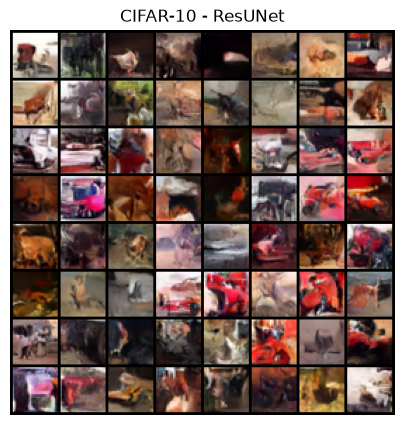

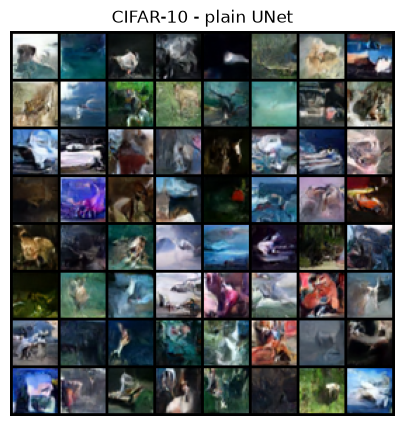

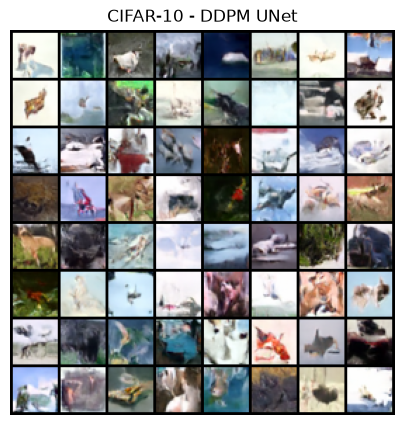

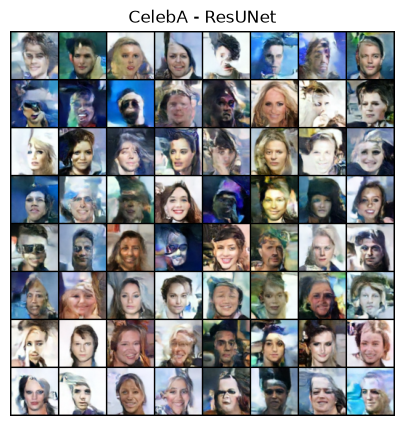

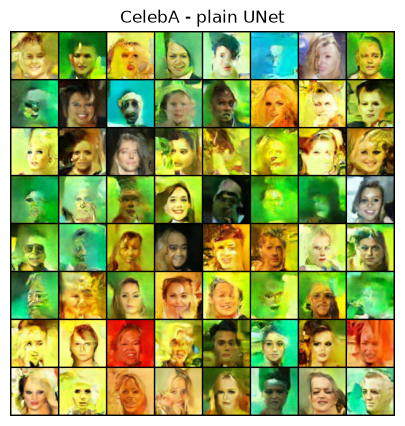

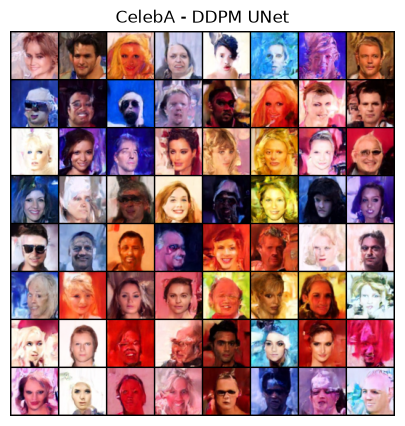

In [9]:
def load_diffusion(dataset, arch):
    state = torch.load(ckpt_path(dataset, arch), map_location=DEVICE, weights_only=True)
    model = build_model(state["arch"], state["dataset"])
    model.load_state_dict(state["model"])
    model.to(DEVICE, memory_format=torch.channels_last).eval()
    return GaussianDiffusion(model, num_steps=state["num_steps"]).to(DEVICE)


def sample_and_save(diffusion, dataset, arch, label, n=64, seed=0):
    size = DATASETS[dataset]["image_size"]
    torch.manual_seed(seed)   # 같은 초기 노이즈에서 출발해야 비교가 된다
    out = diffusion.p_sample_loop((n, 3, size, size), device=DEVICE)
    d = SAMPLE_DIR / dataset
    d.mkdir(parents=True, exist_ok=True)
    # normalize/value_range 를 주지 않으면 [-1,1] 의 음수 픽셀이 0 으로 잘려 나간다
    save_image(out.float(), d / f"samples_{arch}.png", nrow=8,
               normalize=True, value_range=(-1, 1))
    show_grid(out, f"{dataset} - {label}")
    return out


models, samples = {}, {}
for dataset in DATASETS:
    for arch, label in ARCHS:
        models[(dataset, label)] = load_diffusion(dataset, arch)
        samples[(dataset, label)] = sample_and_save(
            models[(dataset, label)], dataset, arch, label)

## 7. 노이즈 제거 과정 애니메이션

`p_sample_loop` 가 돌려주는 실제 역과정 궤적을 쓴다.

51 프레임 -> denoising_process\CIFAR-10_ResUNet.gif


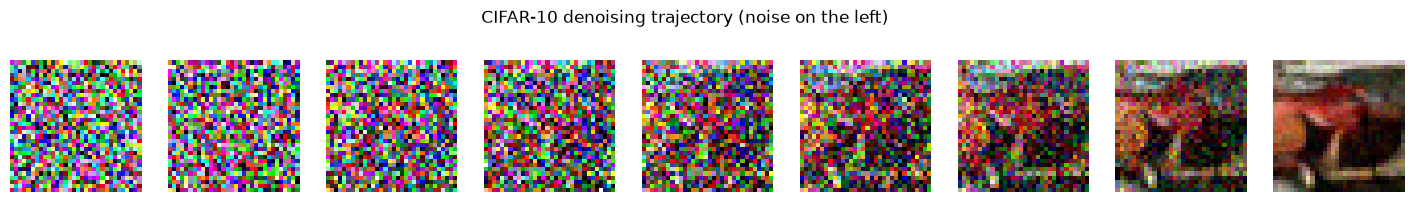

51 프레임 -> denoising_process\CelebA_ResUNet.gif


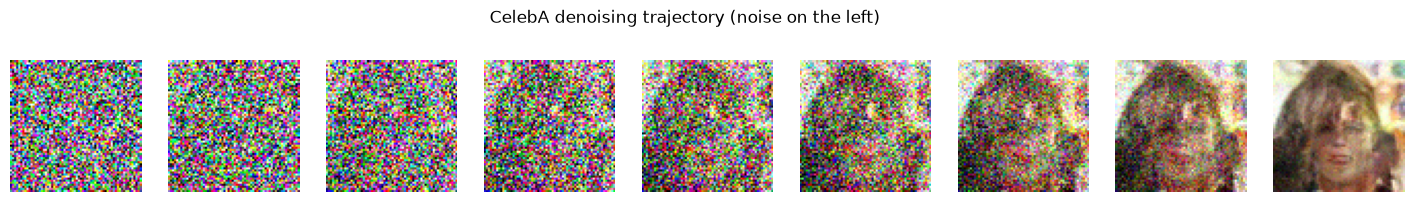

In [10]:
def save_denoising_gif(dataset, label, keep_every=20):
    size = DATASETS[dataset]["image_size"]
    path = Path("denoising_process") / f"{dataset}_{label.replace(' ', '_')}.gif"
    path.parent.mkdir(parents=True, exist_ok=True)

    _, trajectory = models[(dataset, label)].p_sample_loop(
        (1, 3, size, size), device=DEVICE, keep_every=keep_every)
    frames = [Image.fromarray(to_uint8(step[0])) for step in trajectory]

    # PIL 로 직접 저장한다. imageio 의 버전별 fps/duration 인자 차이를 피할 수 있다
    frames[0].save(path, save_all=True, append_images=frames[1:], duration=120, loop=0)
    print(f"{len(frames)} 프레임 -> {path}")
    return frames


for dataset in DATASETS:
    frames = save_denoising_gif(dataset, "ResUNet")
    picks = frames[:: max(1, len(frames) // 8)]
    fig, axes = plt.subplots(1, len(picks), figsize=(2 * len(picks), 2.4))
    for ax, frame in zip(axes, picks):
        ax.imshow(frame)
        ax.axis("off")
    fig.suptitle(f"{dataset} denoising trajectory (noise on the left)")
    plt.show()

## 8. SSIM 진단

SSIM 은 기준 이미지가 필요하므로 **생성 품질 지표가 아니다.** 여기서는
"$t$ 까지 오염된 이미지를 얼마나 되돌리는가"를 재는 노이즈 제거 진단으로만 쓴다.

디스크를 거치지 않고 텐서에서 바로 계산한다. PNG 로 저장했다 다시 읽으면
정규화 범위 때문에 값이 손상된다.

In [11]:
from skimage.metrics import structural_similarity as ssim


@torch.no_grad()
def ssim_at_step(diffusion, images, step, max_images=1000):
    diffusion.model.eval()
    scores = []

    for start in range(0, min(max_images, len(images)), BATCH_SIZE):
        batch = images[start:start + BATCH_SIZE]
        x0 = to_model_input(batch)
        recon = diffusion.denoise_at(x0, step)
        for a, b in zip(x0.float().cpu(), recon.float().cpu()):
            # [-1,1] -> [0,1]. channel_axis 를 주면 채널별 계산을 skimage 가 알아서 평균낸다
            p = (a.permute(1, 2, 0).numpy() + 1) / 2
            q = (b.permute(1, 2, 0).numpy() + 1) / 2
            scores.append(ssim(p, q, data_range=1.0, channel_axis=2))

    return float(np.mean(scores))


STEPS = [50, 100, 200, 400, 600, 800]
ssim_curves = {}
for dataset in DATASETS:
    test_images = DATA[dataset]["test"]
    for arch, label in ARCHS:
        ssim_curves[(dataset, label)] = [
            ssim_at_step(models[(dataset, label)], test_images, s) for s in STEPS]

for dataset in DATASETS:
    header = f"[{dataset}] {'t':>5} | " + " | ".join(f"{label:>11}" for _, label in ARCHS)
    print(header)
    print("-" * len(header))
    for i, s in enumerate(STEPS):
        print(f"{'':>{len(dataset) + 3}}{s:5d} | " +
              " | ".join(f"{ssim_curves[(dataset, label)][i]:11.4f}" for _, label in ARCHS))
    print()

[CIFAR-10]     t |     ResUNet |  plain UNet |   DDPM UNet
----------------------------------------------------------
              50 |      0.9713 |      0.9714 |      0.9715
             100 |      0.9389 |      0.9390 |      0.9399
             200 |      0.8697 |      0.8707 |      0.8747
             400 |      0.7284 |      0.7282 |      0.7391
             600 |      0.5695 |      0.5654 |      0.5824
             800 |      0.3549 |      0.3493 |      0.3622

[CelebA]     t |     ResUNet |  plain UNet |   DDPM UNet
--------------------------------------------------------
            50 |      0.9708 |      0.9710 |      0.9727
           100 |      0.9443 |      0.9452 |      0.9485
           200 |      0.8946 |      0.8955 |      0.9024
           400 |      0.7989 |      0.8002 |      0.8163
           600 |      0.6898 |      0.6899 |      0.7138
           800 |      0.5113 |      0.5008 |      0.5506



## 9. 비교 요약

논문의 중심 주장인 *"residual learning 을 UNet 백본에 결합하면 생성 품질이 개선되는가"*
에 답하는 표다.

데이터셋       | 구조          |       파라미터 |      최종 손실 |    평균 SSIM
------------------------------------------------------------------
CIFAR-10   | ResUNet     |  2,473,475 |    0.06108 |     0.7388
CIFAR-10   | plain UNet  |  2,473,475 |    0.06084 |     0.7373
CIFAR-10   | DDPM UNet   |  2,356,739 |    0.05967 |     0.7449
CelebA     | ResUNet     |  2,612,419 |    0.03716 |     0.8016
CelebA     | plain UNet  |  2,612,419 |    0.03679 |     0.8004
CelebA     | DDPM UNet   |  2,356,739 |    0.03476 |     0.8174


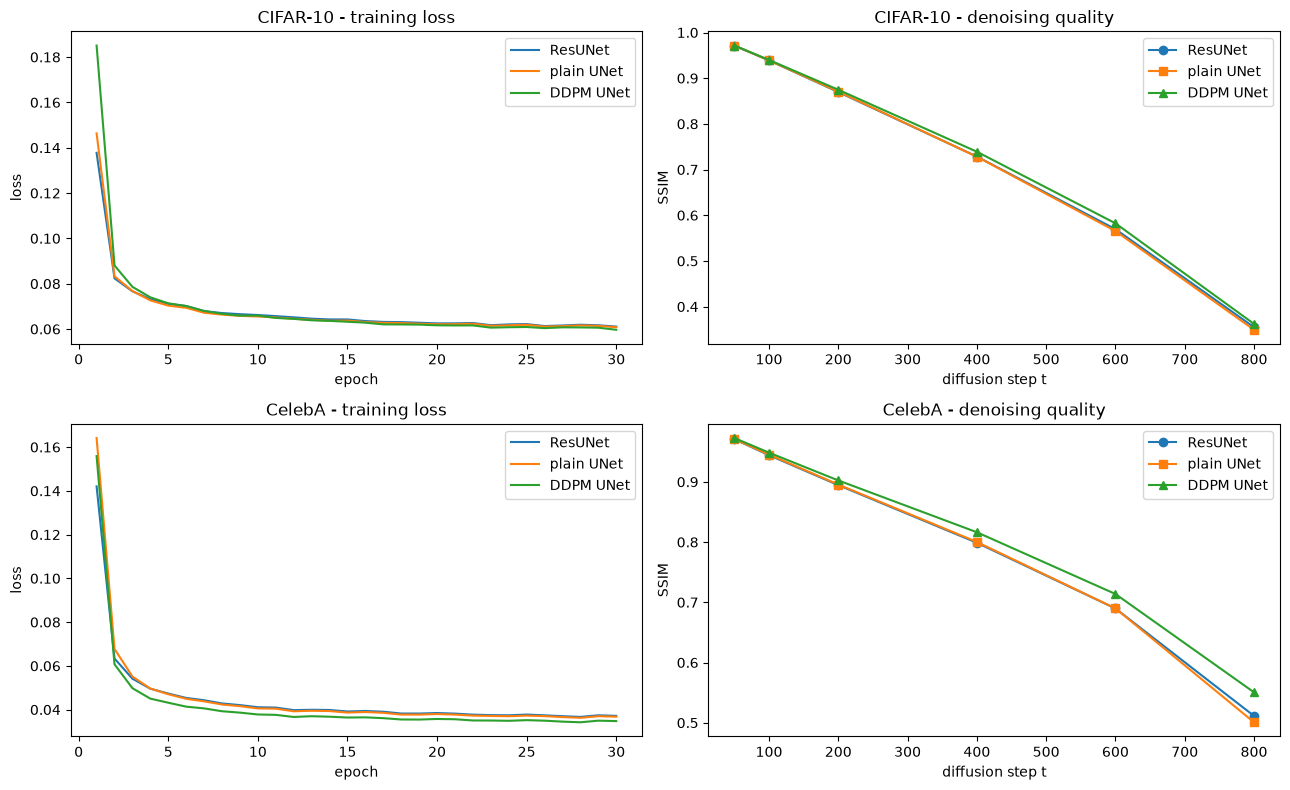

In [12]:
print(f"{'데이터셋':<10} | {'구조':<11} | {'파라미터':>10} | {'최종 손실':>10} | {'평균 SSIM':>10}")
print("-" * 66)
for dataset in DATASETS:
    for arch, label in ARCHS:
        n = sum(p.numel() for p in models[(dataset, label)].model.parameters())
        print(f"{dataset:<10} | {label:<11} | {n:10,} | "
              f"{histories[(dataset, label)][-1]:10.5f} | "
              f"{np.mean(ssim_curves[(dataset, label)]):10.4f}")

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for row, dataset in enumerate(DATASETS):
    for marker, (_, label) in zip("os^", ARCHS):
        h = histories[(dataset, label)]
        axes[row][0].plot(range(1, len(h) + 1), h, label=label)
        axes[row][1].plot(STEPS, ssim_curves[(dataset, label)], marker=marker, label=label)
    axes[row][0].set_title(f"{dataset} - training loss")
    axes[row][0].set_xlabel("epoch"); axes[row][0].set_ylabel("loss"); axes[row][0].legend()
    axes[row][1].set_title(f"{dataset} - denoising quality")
    axes[row][1].set_xlabel("diffusion step t"); axes[row][1].set_ylabel("SSIM")
    axes[row][1].legend()
plt.tight_layout()
plt.show()